# LIBERO Prompt Variant Rollout Analysis

This notebook loads raw rollout output and provides:
- overall statistics
- success-rate heatmap by task and prompt variant
- mean episode-length heatmap by task and prompt variant
- success-rate bar plot by variant with the original prompt as a baseline line

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)

## 2. Load and Parse Raw Output Data

In [2]:
candidate_paths = [
    Path("../language_diagnostics/outputs/libero_prompt_variant_rollouts_raw.csv"),
    Path("language_diagnostics/outputs/libero_prompt_variant_rollouts_raw.csv"),
    Path("outputs/libero_prompt_variant_rollouts_raw.csv"),
]

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find libero_prompt_variant_rollouts_raw.csv. "
        f"Checked: {[str(p) for p in candidate_paths]}"
    )

print(f"Loading data from: {csv_path.resolve()}")
df = pd.read_csv(csv_path)

required_cols = {
    "suite", "task_id", "task_description", "variant_type", "success", "episode_length", "rollout_index"
}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(
        "Missing required columns for analysis: "
        f"{sorted(missing)}. Available columns: {list(df.columns)}"
    )

# Normalize types for robust analysis.
df["success"] = df["success"].astype(bool)
df["episode_length"] = pd.to_numeric(df["episode_length"], errors="coerce")

# Build a readable task label.
df["task_label"] = (
    df["suite"].astype(str)
    + " | task_"
    + df["task_id"].astype(str)
    + " | "
    + df["task_description"].astype(str).str.slice(0, 55)
)

print(f"Rows (rollouts): {len(df)}")
print(f"Unique tasks: {df['task_label'].nunique()}")
print(f"Unique variants: {df['variant_type'].nunique()}")
df.head()

Loading data from: C:\repos\bachelor_project\vla-robotics\language_diagnostics\outputs\libero_prompt_variant_rollouts_raw.csv
Rows (rollouts): 45
Unique tasks: 1
Unique variants: 9


,suite,task_id,task_description,episode_seed_base,variant_type,variant_index,prompt,rollout_index,episode_seed,success,episode_length,task_label
0,spatial,0,pick up the black bowl between the plate and t...,0,original,0,pick up the black bowl between the plate and t...,0,0,True,77,spatial | task_0 | pick up the black bowl betw...
1,spatial,0,pick up the black bowl between the plate and t...,0,original,0,pick up the black bowl between the plate and t...,1,1,True,79,spatial | task_0 | pick up the black bowl betw...
2,spatial,0,pick up the black bowl between the plate and t...,0,original,0,pick up the black bowl between the plate and t...,2,2,True,69,spatial | task_0 | pick up the black bowl betw...
3,spatial,0,pick up the black bowl between the plate and t...,0,original,0,pick up the black bowl between the plate and t...,3,3,True,72,spatial | task_0 | pick up the black bowl betw...
4,spatial,0,pick up the black bowl between the plate and t...,0,original,0,pick up the black bowl between the plate and t...,4,4,True,72,spatial | task_0 | pick up the black bowl betw...


## 3. Calculate Overall Statistics

In [3]:
overall = {
    "num_rollouts": len(df),
    "num_tasks": df["task_label"].nunique(),
    "num_variants": df["variant_type"].nunique(),
    "overall_success_rate": df["success"].mean(),
    "overall_mean_episode_length": df["episode_length"].mean(),
    "overall_median_episode_length": df["episode_length"].median(),
}

overall_df = pd.DataFrame([overall])
overall_df[["overall_success_rate"]] = overall_df[["overall_success_rate"]] * 100
overall_df = overall_df.rename(columns={"overall_success_rate": "overall_success_rate_percent"})
display(overall_df.round(2))

per_variant = (
    df.groupby("variant_type", as_index=False)
    .agg(
        rollouts=("success", "size"),
        success_rate=("success", "mean"),
        mean_episode_length=("episode_length", "mean"),
        median_episode_length=("episode_length", "median"),
    )
    .sort_values("success_rate", ascending=False)
)
per_variant["success_rate_percent"] = per_variant["success_rate"] * 100
display(per_variant.round(2))

,num_rollouts,num_tasks,num_variants,overall_success_rate_percent,overall_mean_episode_length,overall_median_episode_length
0,45,1,9,64.44,152.78,87.0


,variant_type,rollouts,success_rate,mean_episode_length,median_episode_length,success_rate_percent
2,do_not_move,5,1.0,76.4,77.0,100.0
3,original,5,1.0,73.8,72.0,100.0
4,politeness,5,1.0,76.8,76.0,100.0
6,sentence_structure,5,1.0,86.2,88.0,100.0
7,verb_paraphrase,5,1.0,70.0,67.0,100.0
0,carefully,5,0.6,192.6,245.0,60.0
5,quickly,5,0.2,239.2,280.0,20.0
1,contrastive_negation,5,0.0,280.0,280.0,0.0
8,verbosity,5,0.0,280.0,280.0,0.0


## 4. Create Success vs Task Heatmap

C:\Users\celin\AppData\Local\Temp\ipykernel_31200\517238844.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


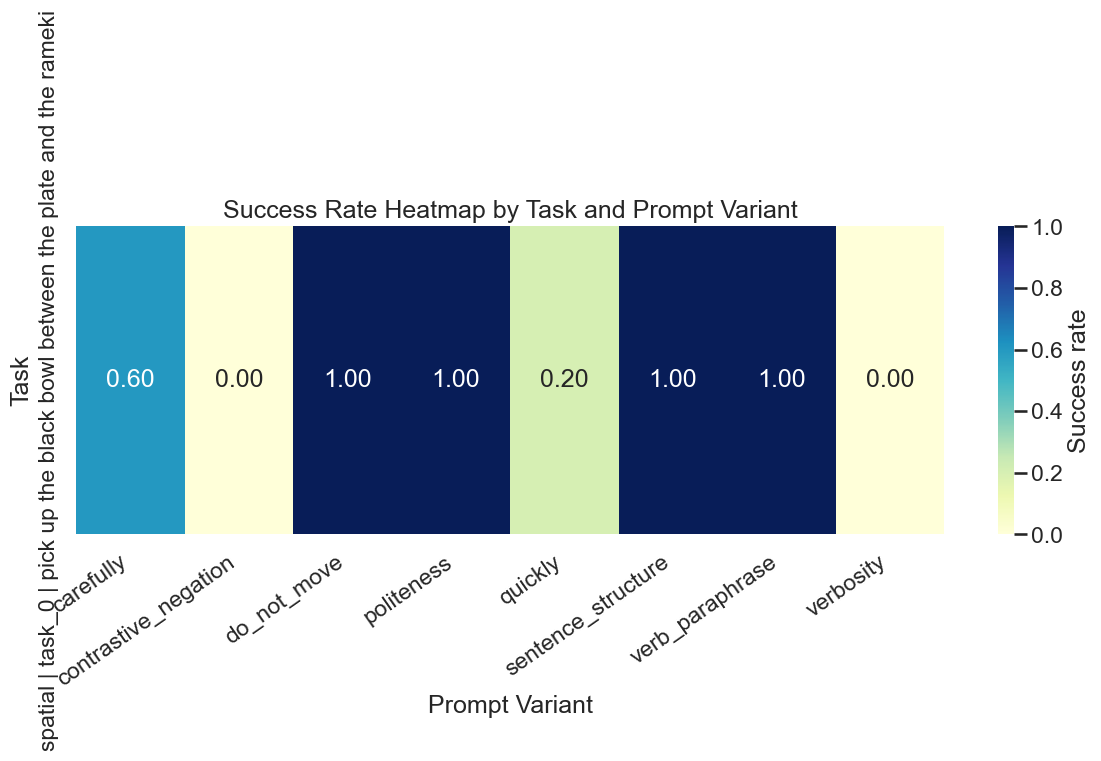

In [7]:
success_pivot = (
    df[df["variant_type"] != "original"].groupby(["task_label", "variant_type"], as_index=False)["success"]
    .mean()
    .pivot(index="task_label", columns="variant_type", values="success")
)

plt.figure(figsize=(14, max(4, 0.7 * len(success_pivot))))
ax = sns.heatmap(
    success_pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Success rate"},
)
ax.set_title("Success Rate Heatmap by Task and Prompt Variant")
ax.set_xlabel("Prompt Variant")
ax.set_ylabel("Task")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 5. Create Mean Episode Length vs Task Heatmap

C:\Users\celin\AppData\Local\Temp\ipykernel_31200\2343321934.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


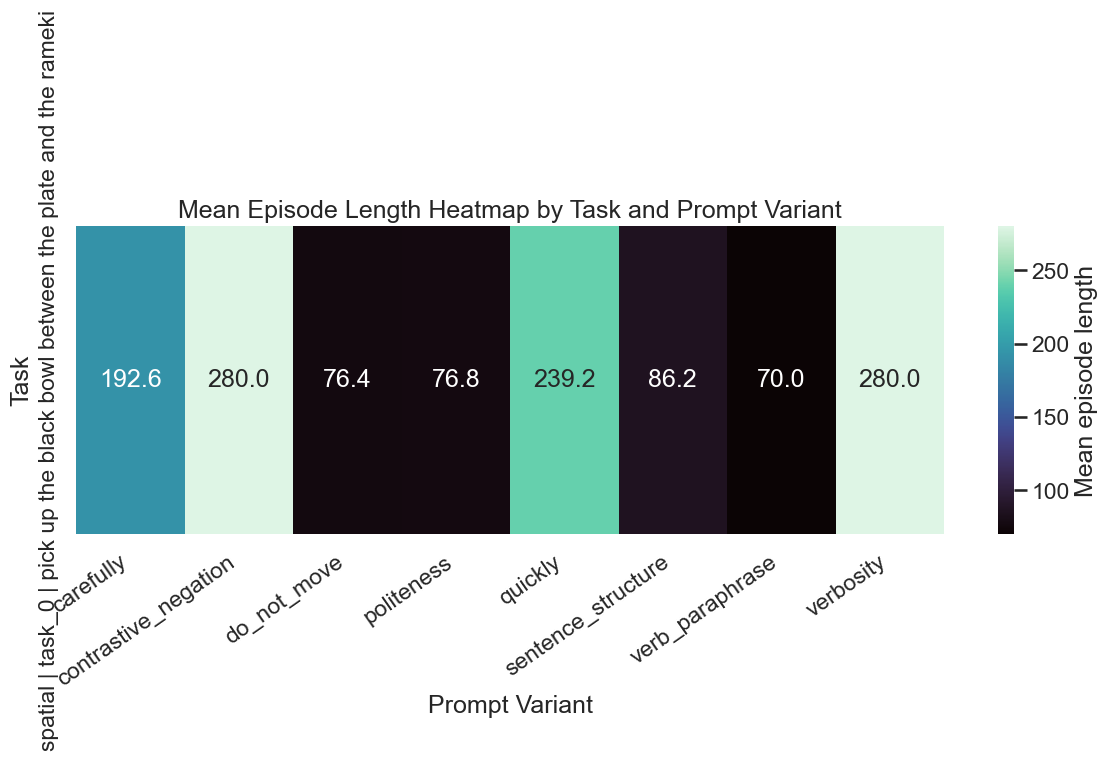

In [8]:
length_pivot = (
    df[df["variant_type"] != "original"].groupby(["task_label", "variant_type"], as_index=False)["episode_length"]
    .mean()
    .pivot(index="task_label", columns="variant_type", values="episode_length")
)

plt.figure(figsize=(14, max(4, 0.7 * len(length_pivot))))
ax = sns.heatmap(
    length_pivot,
    annot=True,
    fmt=".1f",
    cmap="mako",
    cbar_kws={"label": "Mean episode length"},
)
ax.set_title("Mean Episode Length Heatmap by Task and Prompt Variant")
ax.set_xlabel("Prompt Variant")
ax.set_ylabel("Task")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 6. Create Success Rate Bar Plot with Baseline Comparison

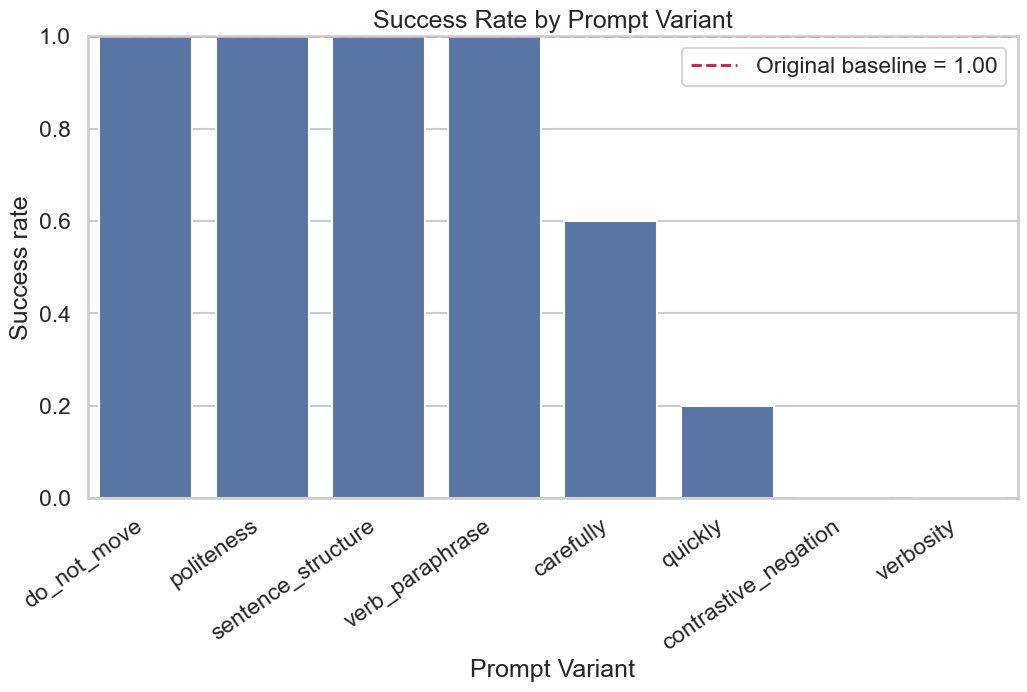

<Figure size 640x480 with 0 Axes>

In [11]:
variant_success = (
    df.groupby("variant_type", as_index=False)["success"]
    .mean()
    .sort_values("success", ascending=False)
)

original_row = variant_success.loc[variant_success["variant_type"] == "original", "success"]
if original_row.empty:
    raise ValueError("No 'original' variant found in data. Cannot draw baseline line.")
original_baseline = float(original_row.iloc[0])

# Remove 'original' from the bar plot (keep only variants)
variant_success_plot = variant_success[variant_success["variant_type"] != "original"]

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=variant_success_plot, x="variant_type", y="success", color="#4C72B0")
ax.axhline(
    original_baseline,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Original baseline = {original_baseline:.2f}",
)
ax.set_title("Success Rate by Prompt Variant")
ax.set_xlabel("Prompt Variant")
ax.set_ylabel("Success rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=35, ha="right")

ax.legend()
plt.show()
plt.tight_layout()